# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [2]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [3]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [5]:
features = np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets = np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')



In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [7]:
df.RR_Lyrae.value_counts()

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

- R1: corresponde a un problema de clasificación, ya que el problema se basa en definir si una estrella es o no es RR Lyrae.
- R2: corresponde a un problema binario, ya que 0= no es RR Lyrae y 1= es RR Lyrae
- R3: la variable objetivo representa el si la estrella es tipo RR Lyrae o no.
- R4: las clases estan desbalanceadas, ya que hay una cantidad dispareja de estrellas que son RR Lyrae con las que no lo son.
- R5: es importante porque no funcionan todas de buena manera (representativas) ante clases desbalanceadas.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

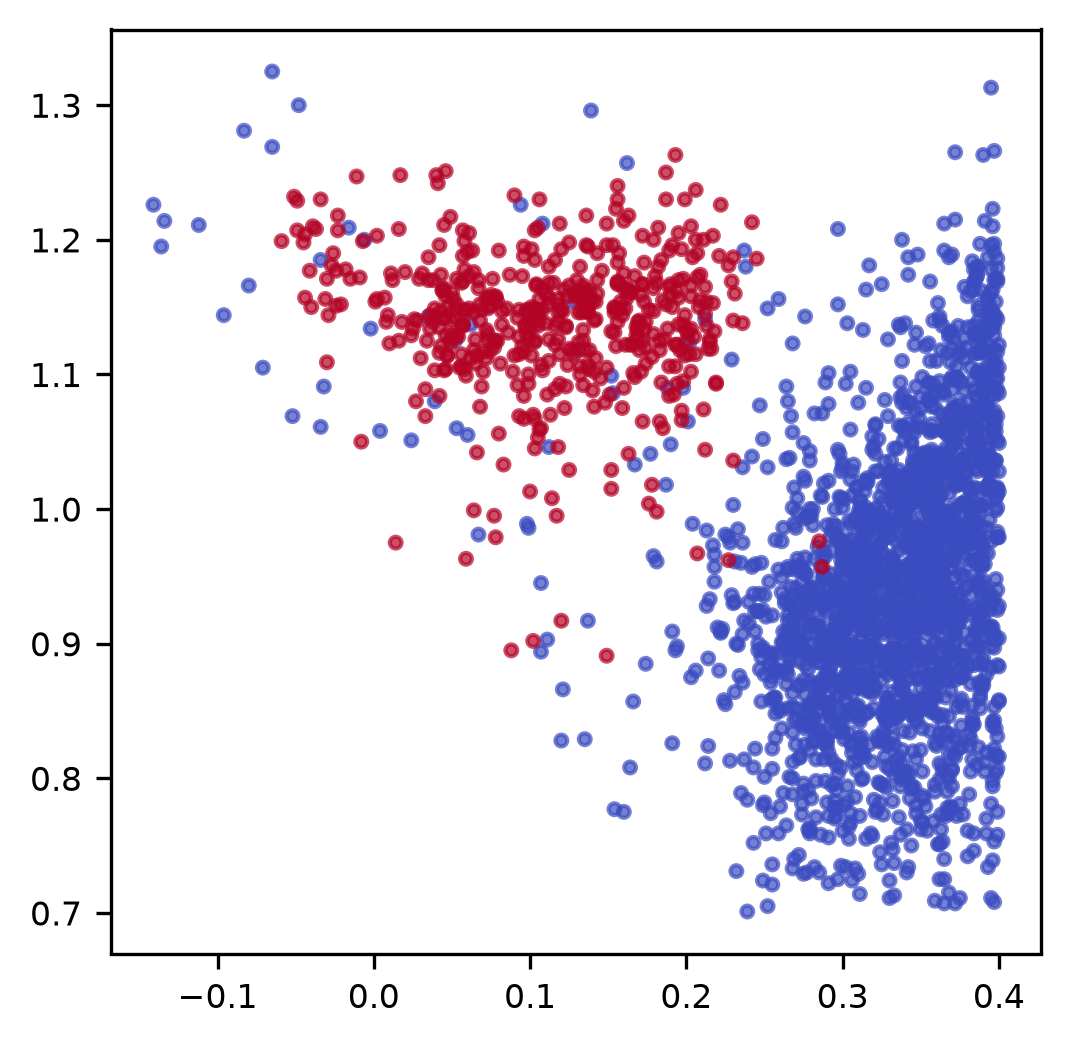

In [8]:

plt.figure(figsize=(4,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

- R1: en el gráfico se puede ver que más o menos trazando una recta y=x que en la diagonal superior se ven más puntos rojos y abajo predominan los azules.
- R2: considerando la cantidad de datos y que se tienen features bien definidas creo que no debería funcionar mal. aunque sabiendo que el arbol de desición varía mucho ante pequeños cambios, podría también ser que presente mucho cambios y no sea tan razonable.

#### Separe los datos en entrenamiento y prueba

In [9]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [10]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [11]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

- R1: como sabemos que no tenemos un problema balanceado, sino que tenemos muchas mas estrellas que no son RR Lyrae que las que si lo son, al hacer divisiones de manera aleatoria es muy probable que en esos "subconjuntos" quedemos sin estrellas catalogadas como RR Lyrae o con muy pocas.
- R2: podría afectar porque por ejemplo, las métricas obtenidas dejarían de ser confiables. Si el conjunto de prueba termina casi sin estrellas RR Lyrae, el modelo podría limitarse a predecir siempre la clase mayoritaria y aun así obtener un accuracy" y esto nos daría la falsa sensación de tener un modelo muy bueno.
- R3: La mejor precaución es asegurarnos de que la proporción de los tipos de estrellas se mantenga iguales al separar los grupos, o sea que tendríamos que forzar la división para que tanto en el grupo de entrenamiento como en el de prueba haya exactamente ese mismo porcentaje.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [12]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


In [13]:
#### Visualicemos el árbol

In [14]:
plt.figure(figsize=(30,30))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

In [15]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

InvocationException: GraphViz's executables not found

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

- R1: el arbol parece bastante complejo, ya que se observa que tiene una catidad grande de niveles (es muy profundo, con 14 niveles) y realiza multiples ramificaciones.
- R2: la principal desventaja de un arbol complejo en este caso es que se generará un gran sobreajuste. Esto significa que el arbol intetará "memorizar" los datos de entrenamiento, haciendo un sobreajuste en ellos, por lo que con ese dataset funcionará increible, pero luego con el test set funcionará mal porque no podrá ajustar bien a un dato nuevo que se escapa de lo que ya conocía.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [16]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.978523489932886


#### Otras métricas

In [17]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.951048951048951
Recall   : 0.9379310344827586
F1-score : 0.9444444444444444


In [18]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[593,   7],
       [  9, 136]])

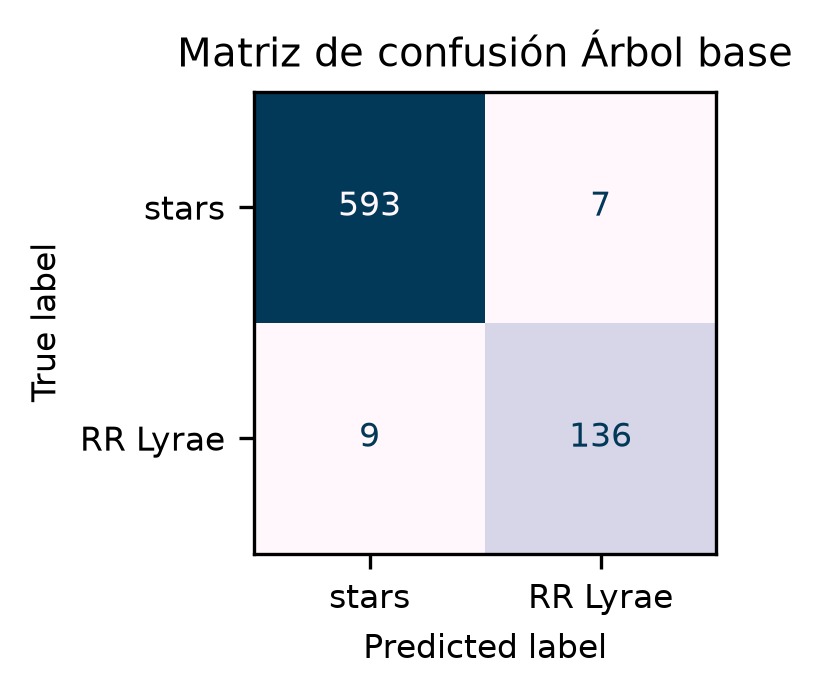

In [19]:
fig, ax = plt.subplots(figsize=(2,2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)

2. Calcule las métricas "a mano"

In [20]:
TP = 136
TN = 593
FP = 7
FN = 9

In [21]:
accuracy = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP)
recall = TP/(TP+FN)
print("accuracy =", accuracy)
print("precision =", precision)
print ("recall =", recall )


accuracy = 0.978523489932886
precision = 0.951048951048951
recall = 0.9379310344827586


In [22]:
F1 = 2*((precision*recall)/(precision+recall))
print("F1 score", F1)

F1 score 0.9444444444444445


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

- R1: en este problema un falso positivo indica que la predicción clasificó a una estrella como RR Lyrae, pero en realidad no lo era. Por otra parte, un falso negativo en este caso sería que la predicción indicó que una estrella no era RR Lyrae y en verdad (basado en lo real) si lo era. 

- R2: Si el objetivo fuera encontrar la mayor cantidad posible de RR Lyrae, estamos hablando de que buscamos una mayor completitud, por tanto queremos un recall más alto. Por lo que nos preocuparía más tener muchos falsos negativos que falsos positivos.

- R3: ahora, si el objetivo fuera construir una muestra mucho mas limpia, o sea que nos interesa la pureza, vemos que nos sirve un valor de precision mucho mas alto. Por tanto sería mucho más preocupante tener muchos falsos positivos que falsos negativos.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [23]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [24]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x12c119250>

In [25]:
for train, test in cv1.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [26]:
for train, test in cv2.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [27]:
for train, test in cv3.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [28]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [29]:
scores3

{'fit_time': array([0.00302482, 0.00245595, 0.00279093, 0.003016  , 0.00260711]),
 'score_time': array([0.00087309, 0.00074506, 0.0007689 , 0.0009861 , 0.00072885]),
 'test_score': array([0.97585513, 0.96579477, 0.96579477, 0.97983871, 0.96169355])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [30]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.784 0.379


In [31]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.966 0.011


In [32]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.970 0.007


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [33]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [34]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [35]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [36]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.907 1.000
0.927 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [37]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [38]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [39]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [40]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [41]:
np.sum(y_cv2)

np.int64(485)

In [42]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [43]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [44]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [45]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [46]:
model = DecisionTreeClassifier(random_state = 5)

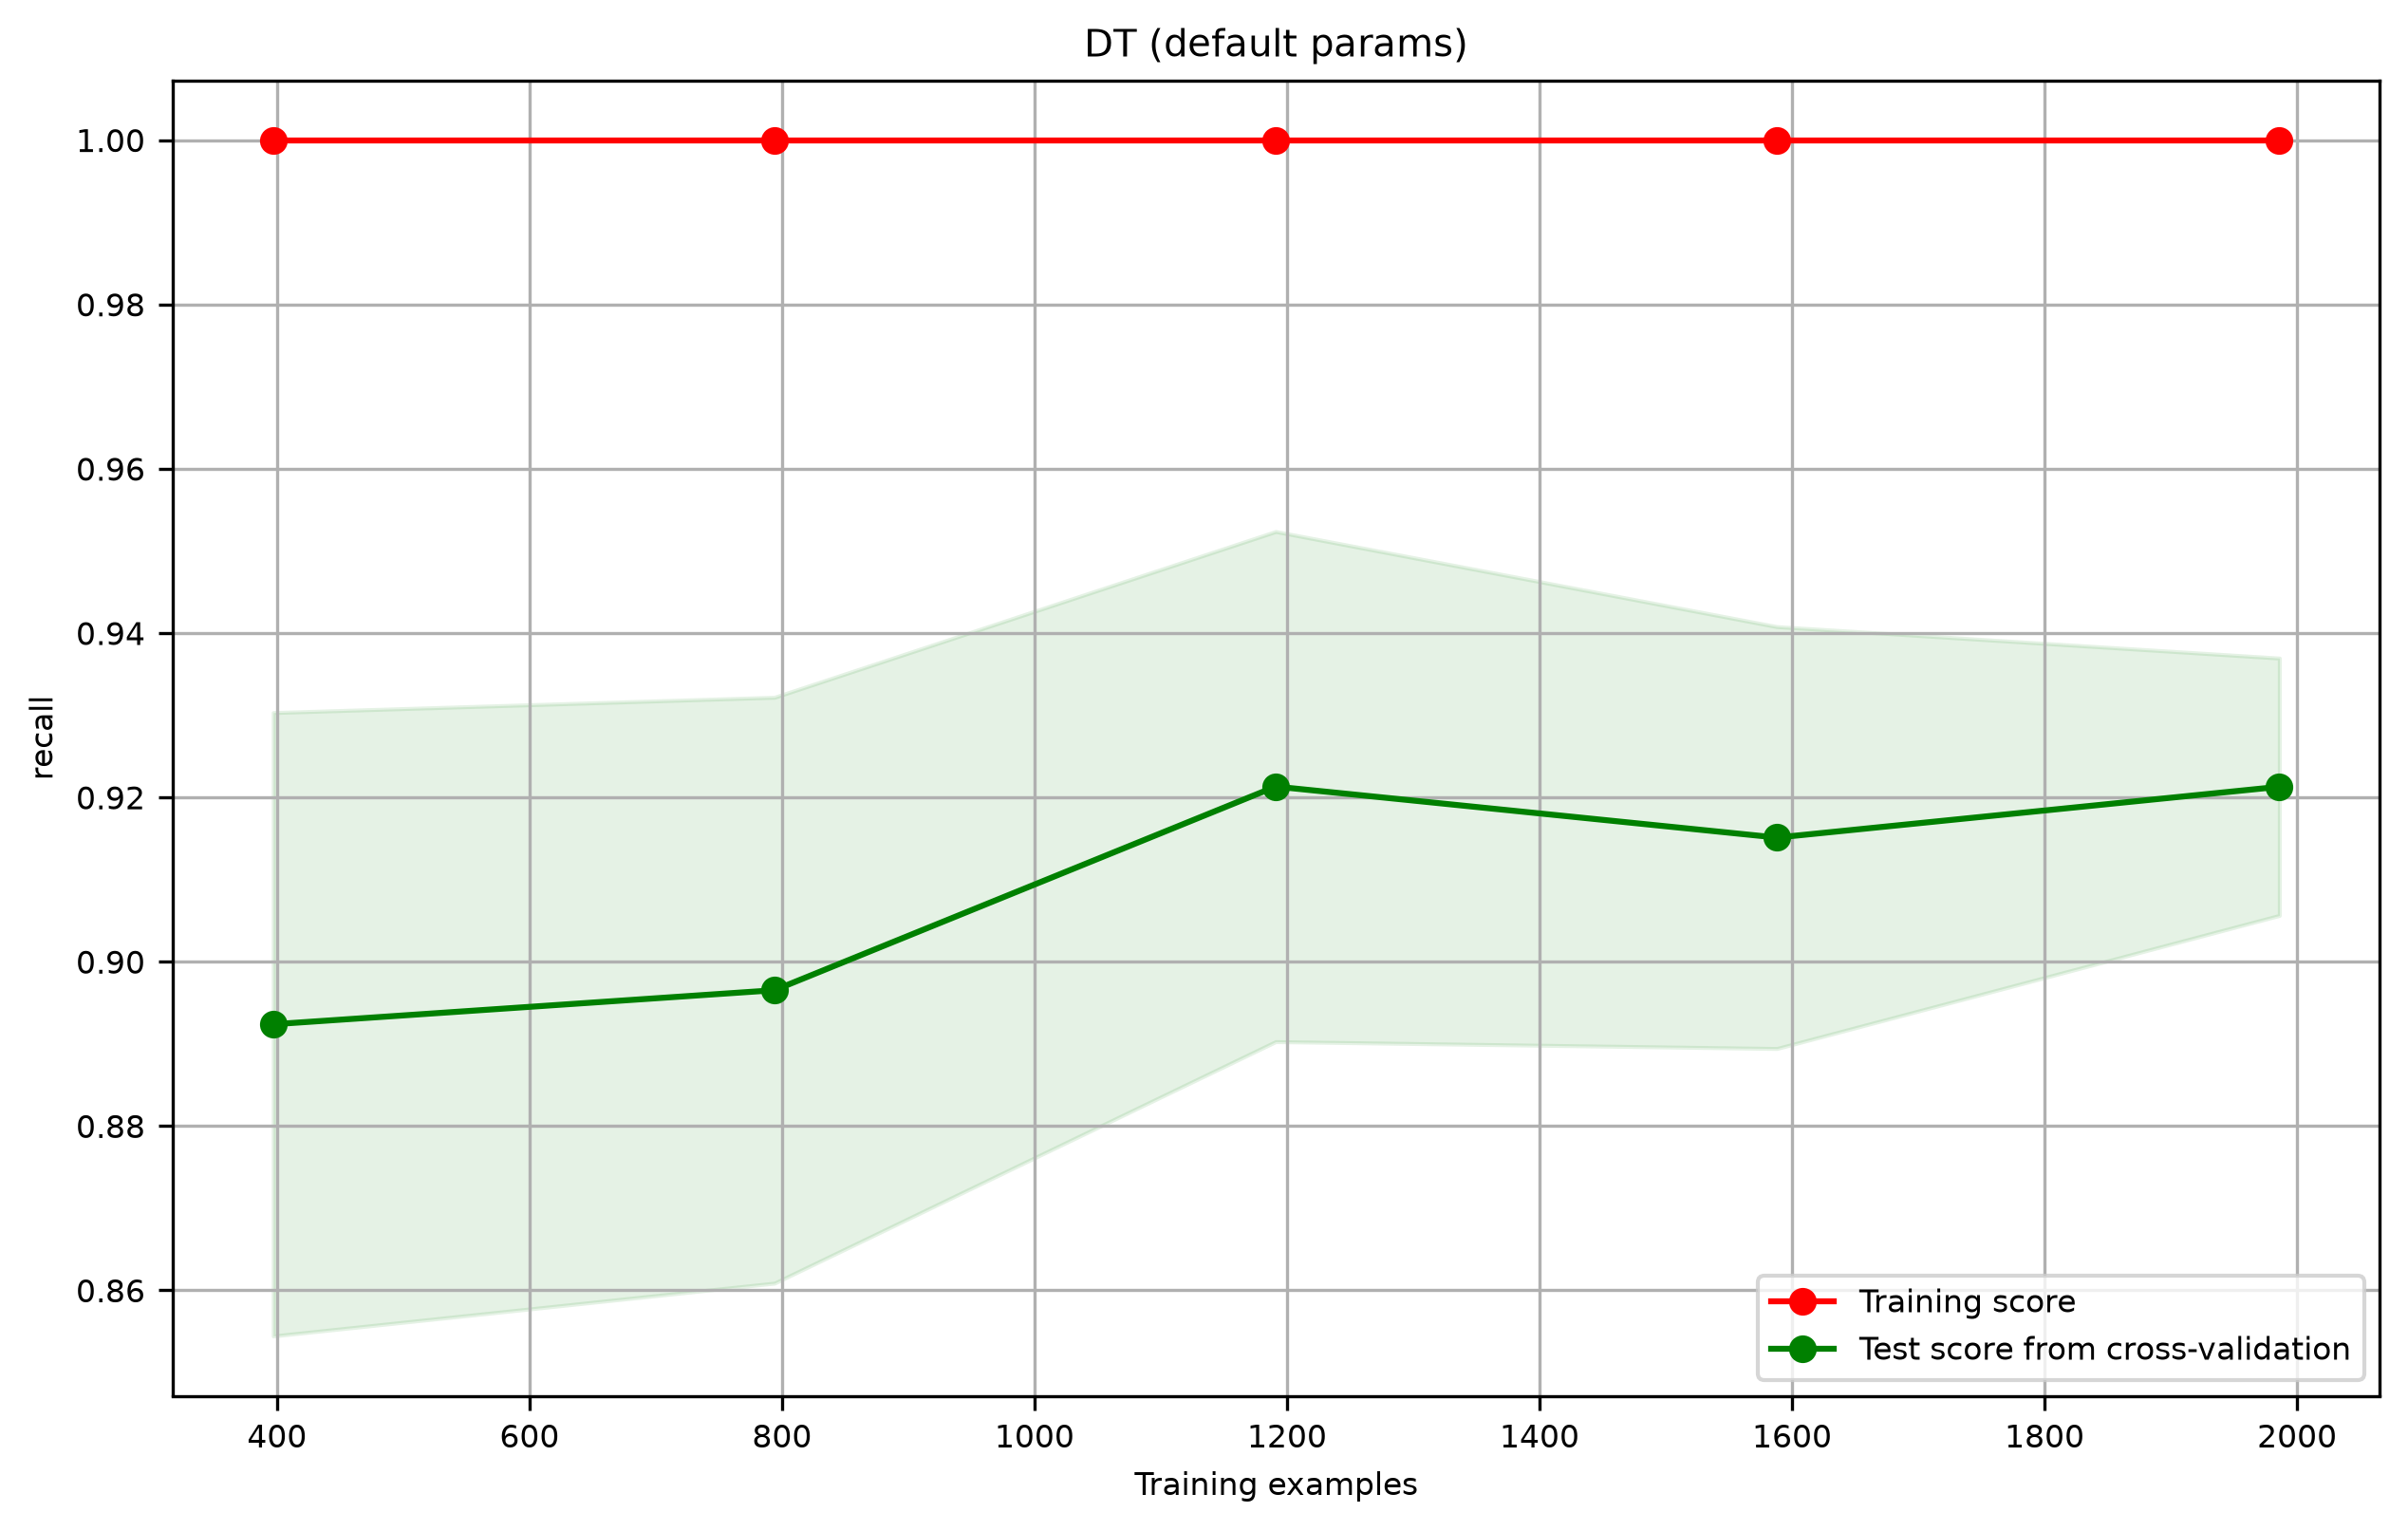

In [47]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

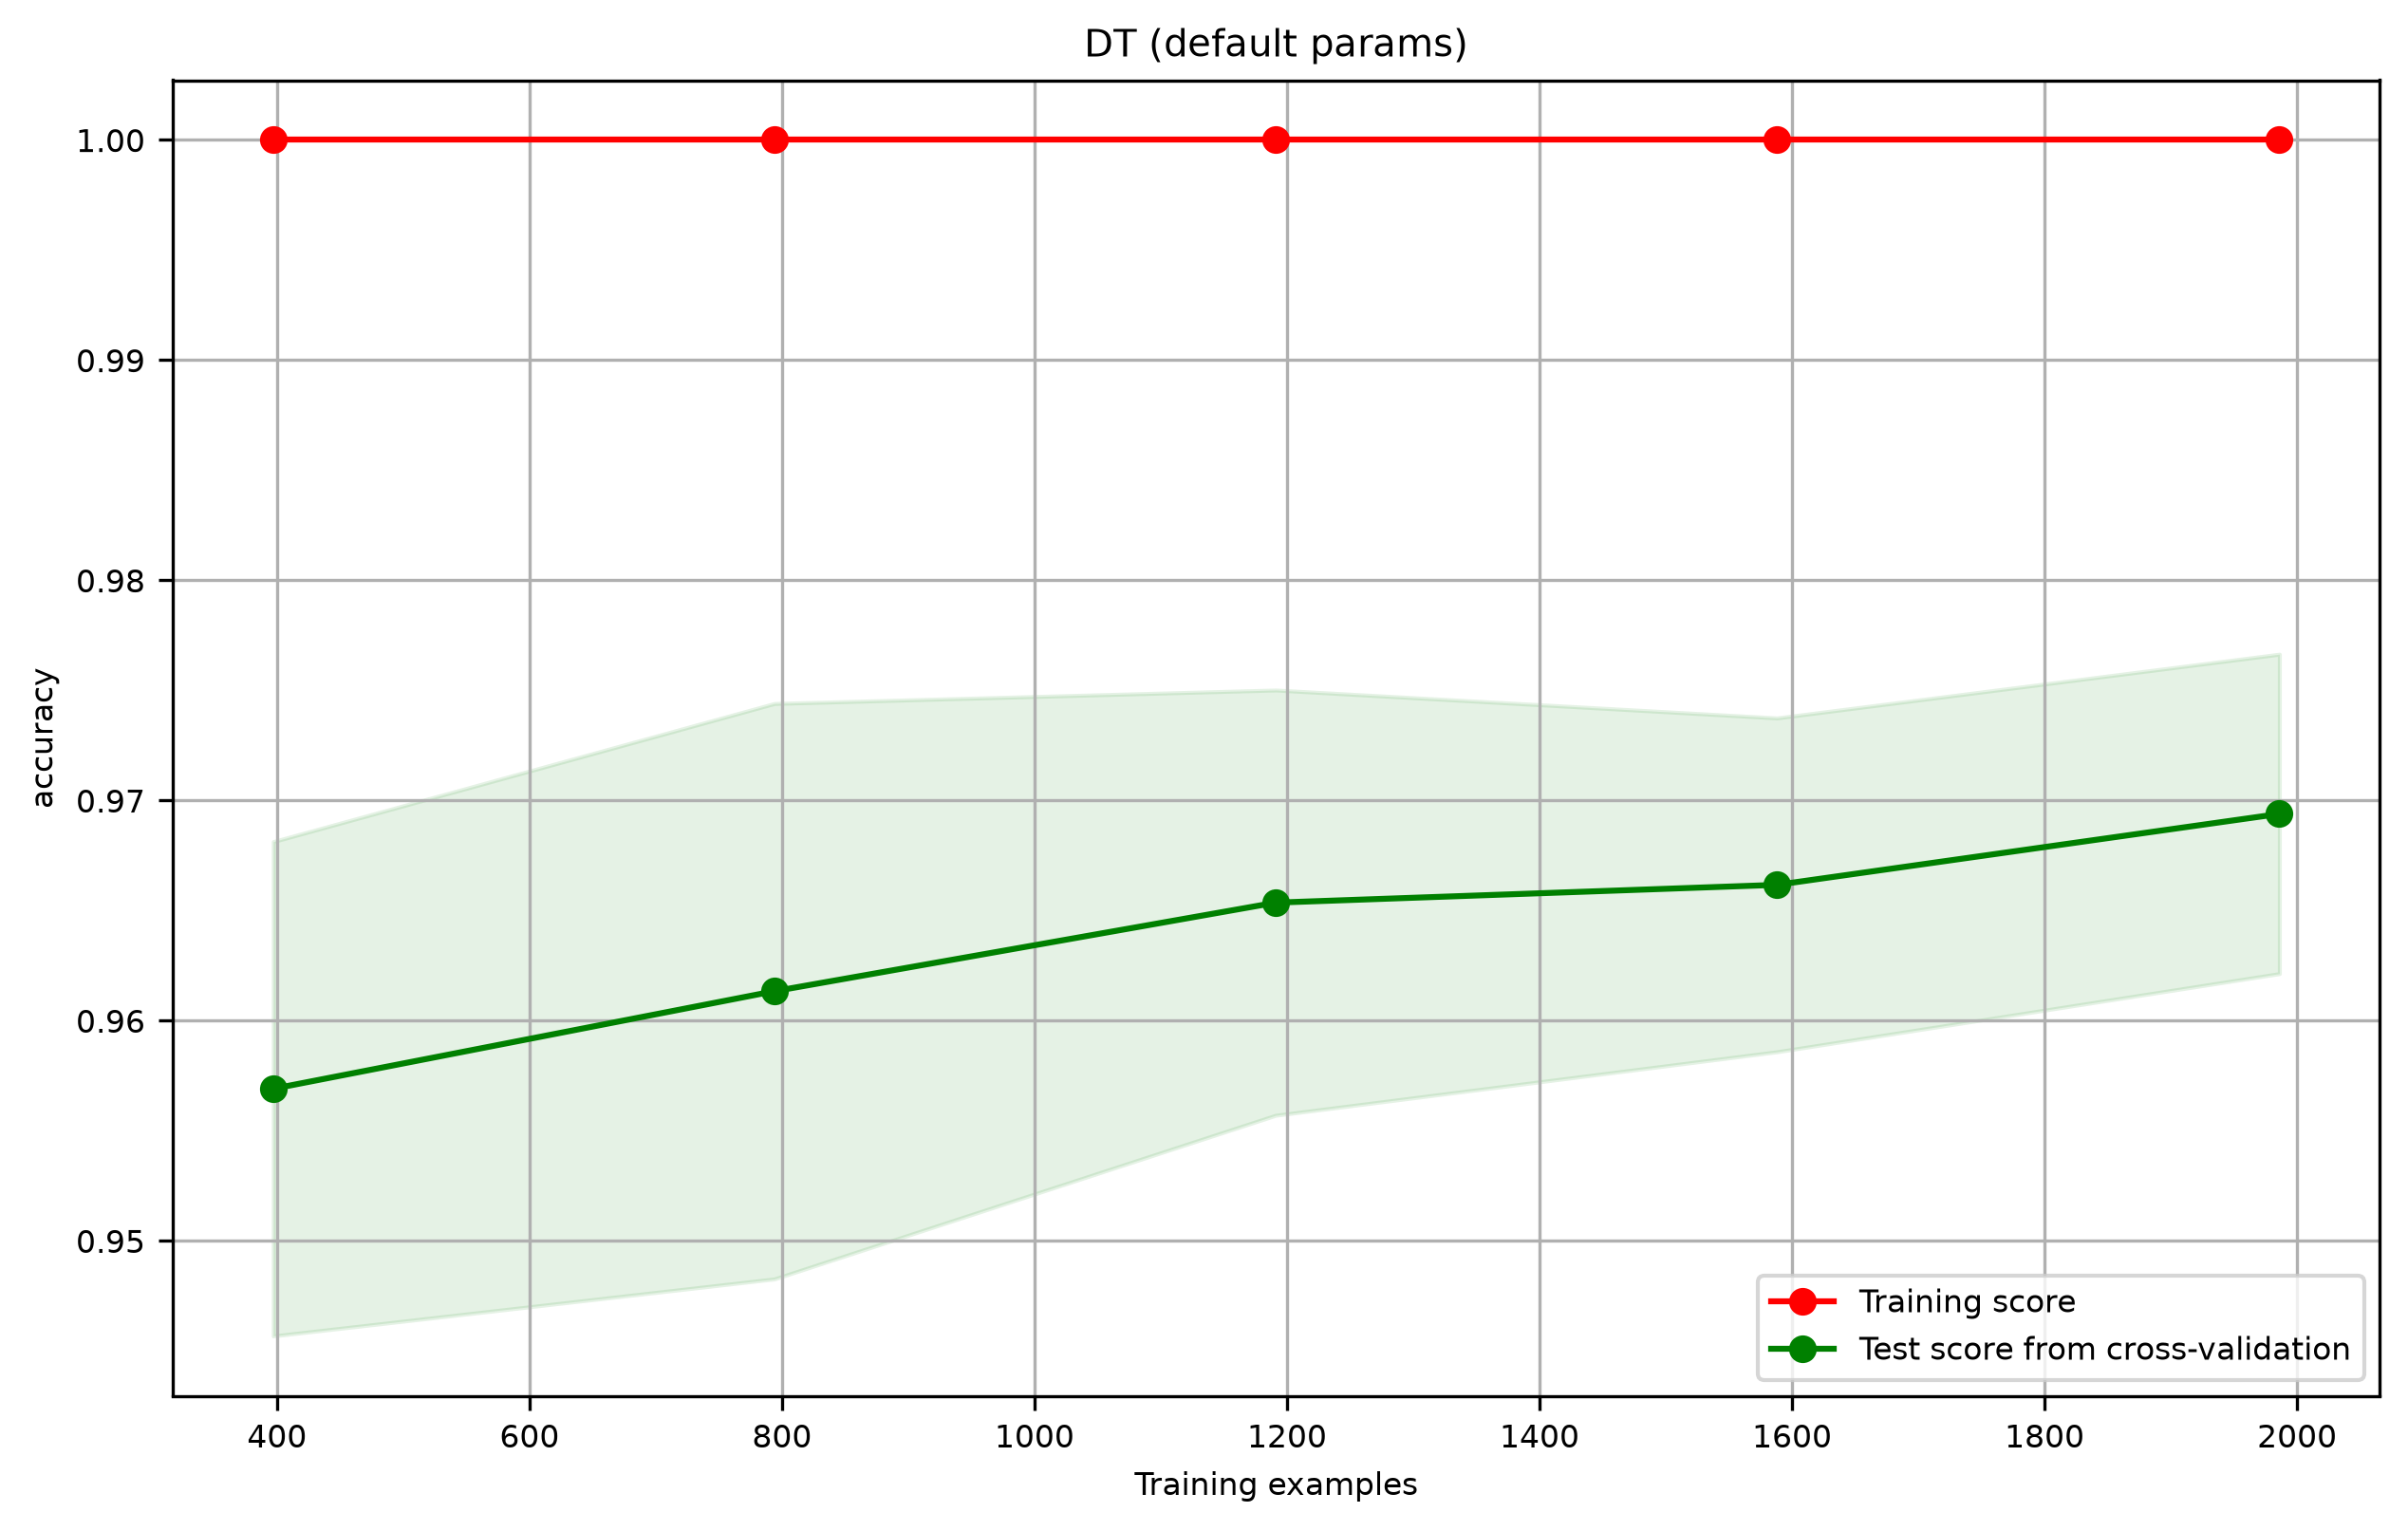

In [48]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

- R1: si existe una brecha evidente entre ambas curvas, porque la curva de entrenamiento se mantiene en 1.0 todo el tiempo, mientras que la curva de validación está mucho más abajo. Esto sugiere que el modelo presenta overfitting, o sea que está memorizando los datos de entrenamiento por lo que tiene problemas para generalizar esas reglas para datos nuevos.

- R2: a mi parecer si mejora porque si vemos la curva verde, mientras más datos de ejemplos se tienen, mejor es el valor de la métrica.

- R3: aquí hablaría de alta varianza (alto sobreajuste u overfitting), ya que como la curva roja (de datos de entrenamiento) tiene un ajuste perfecto al 100% y la curva de los datos de prueba está más abajo, se ve que el modelo se ajustó demasiado a los datos de entrenamiento y luego tenía problemas con datos nuevos. Descartaría el subajuste o alto sesgo porque el modelo efectivamente es capaz de aprenderse los datos de entrenamiento a la perfección (1.0).

- R4: como conclusión puedo decir que el arbol de decisión base es muy flexible y tiende a ser muy complejo también, lo que lo lleva a un gran sobreajuste al memorizar por completo el set de entrenamiento. Se ve también que aunque agregar más datos ayuda notablemente a subir el puntaje de validación, la brecha sigue siendo grande.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [49]:
metricas_cv = ['accuracy', 'precision', 'recall', 'f1']

arbol_base = DecisionTreeClassifier(random_state=42)
arbol_restringido = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)

modelos_dict = {
    'Árbol base': arbol_base,
    'Árbol restringido (min_samples_leaf=10)': arbol_restringido
}

resultados = {}
for nombre, modelo in modelos_dict.items():
    resultados[nombre] = {}
    for metrica in metricas_cv:
        scores = cross_validate(modelo, X, y, cv=cv3, scoring=metrica)['test_score']
        resultados[nombre][metrica] = f"{scores.mean():.3f} ± {scores.std():.3f}"

tabla_comparacion = pd.DataFrame(resultados).T
tabla_comparacion

,accuracy,precision,recall,f1
Árbol base,0.971 ± 0.004,0.920 ± 0.012,0.932 ± 0.014,0.926 ± 0.011
Árbol restringido (min_samples_leaf=10),0.973 ± 0.008,0.923 ± 0.023,0.940 ± 0.030,0.931 ± 0.020


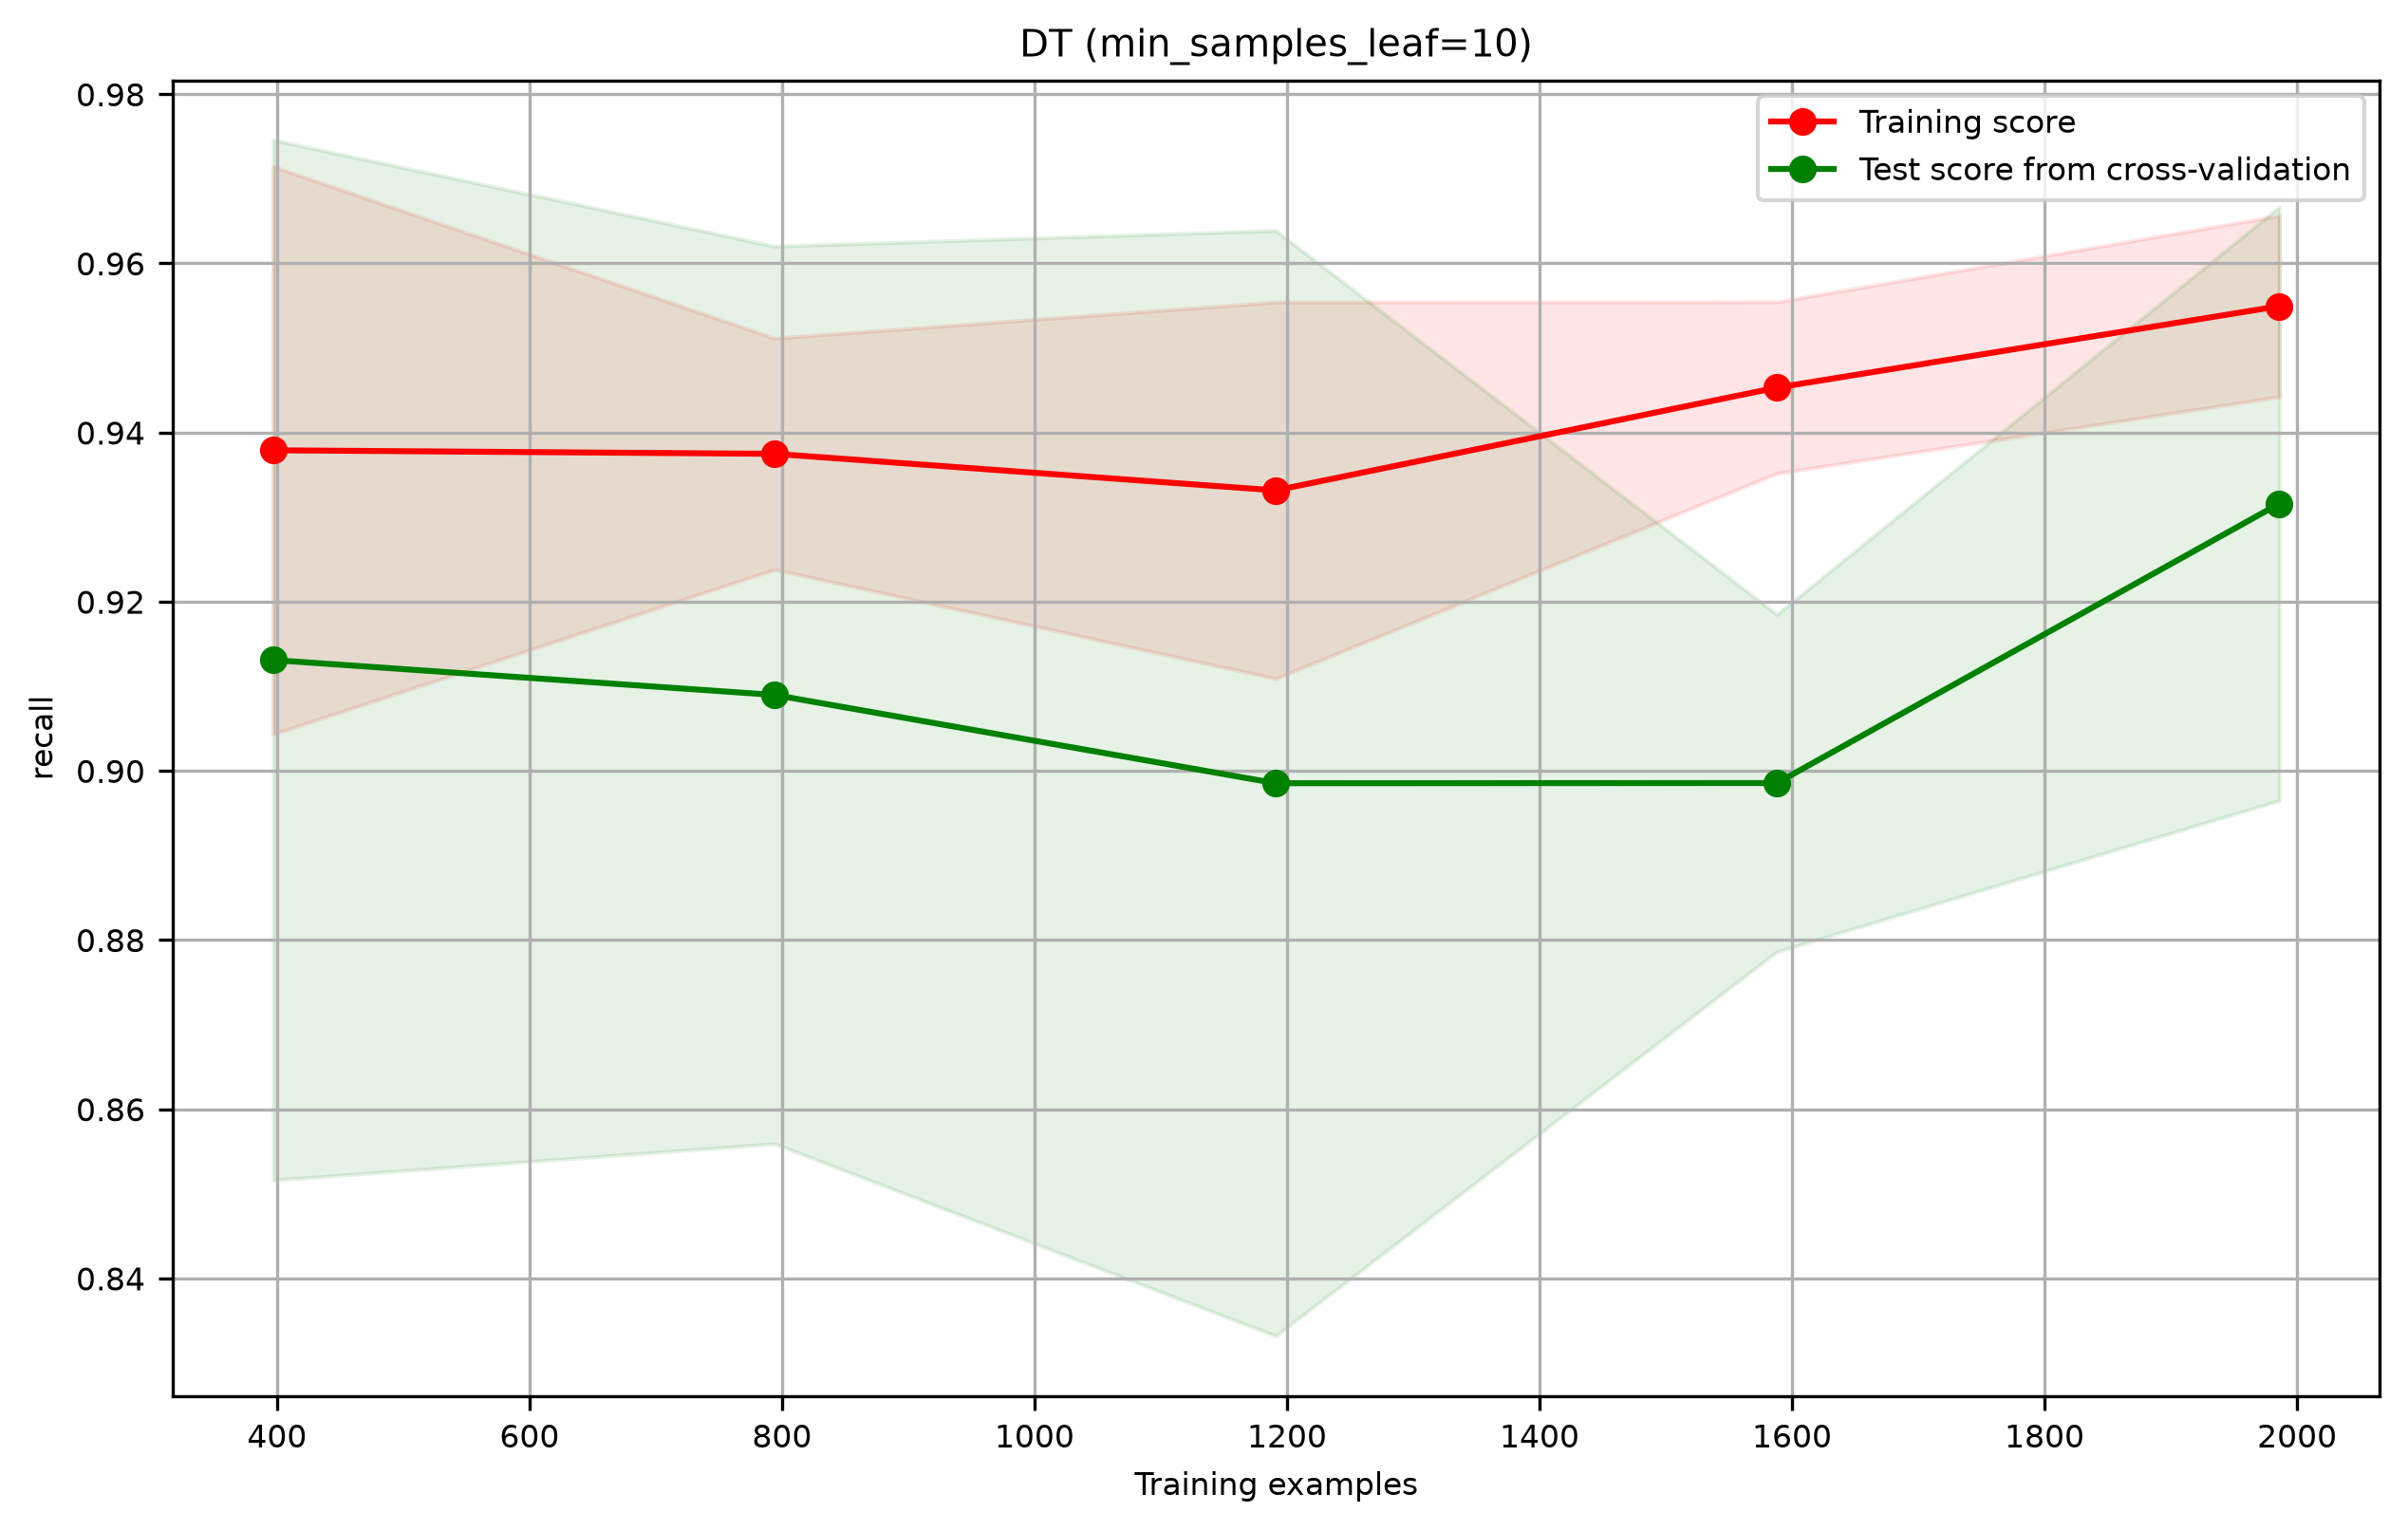

In [53]:
plot_learning_curve(
    arbol_restringido,
    'DT (min_samples_leaf=10)',
    X, y,
    cv=cv3,
    scoring='recall'
);

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

- R1: el rendimiento mejoró levemente en las cuatro métricas: accuracy 0.973, precision 0.923, recall 0.940 y F1 0.931, todas por sobre el árbol base.

- R2: el arbol mas simple mejoró la generalización, ya que el árbol restringido superó al árbol base en todas las métricas evaluadas con validación cruzada y si vemos la curva de los datos de entrenamiento, vemos que para el arbol restringido ya no se tiene en 1 sino que ajusta aprox en 0.94 hacia arriba pero nu en 1 cte.

- R3: Sugieren que el árbol base era innecesariamente complejo y presentaba overfitting, lo cual no era util al momento de ingresar los datos de prueba porque no reconocía nada que no hubiese memorizado con el training set.

- R4: No parece conveniente, ya que el árbol restringido logra mejor rendimiento siendo más simple, interpretable y menos propenso a sobreajuste.

- R5: El recall me parece más importante, porque es la métrica que más mejoró y es la más relevante para no perder RR Lyrae reales.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

(PREGUNTAS RESPONDIDAS ABAJO DE LOS CODIGOS DE ESTA SECCIÓN)

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline_knn5 = Pipeline([
    ('escalado', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

resultados_knn5 = {}
for metrica in metricas_cv:
    scores = cross_validate(pipeline_knn5, X, y, cv=cv3, scoring=metrica)['test_score']
    resultados_knn5[metrica] = f"{scores.mean():.3f} ± {scores.std():.3f}"

pd.Series(resultados_knn5, name='kNN (k=5)')

accuracy     0.978 ± 0.006
precision    0.922 ± 0.021
recall       0.969 ± 0.011
f1           0.945 ± 0.015
Name: kNN (k=5), dtype: str

In [56]:
valores_k = [2, 4, 7, 15, 25, 40]
filas = []

for k in valores_k:
    pipe = Pipeline([('escalado', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    fila = {'k': k}
    for metrica in metricas_cv:
        fila[metrica] = cross_validate(pipe, X, y, cv=cv3, scoring=metrica)['test_score'].mean()
    filas.append(fila)

tabla_knn = pd.DataFrame(filas).set_index('k').round(3)
tabla_knn

,accuracy,precision,recall,f1
k,,,,
2,0.968,0.941,0.892,0.916
4,0.977,0.933,0.950,0.942
7,0.978,0.918,0.975,0.946
15,0.974,0.900,0.975,0.936
25,0.971,0.893,0.971,0.930
40,0.972,0.894,0.971,0.931


In [57]:
comparacion_final = pd.DataFrame({
    'kNN (k=5)': resultados_knn5,
    'Árbol restringido': tabla_comparacion.loc['Árbol restringido (min_samples_leaf=10)']
})
comparacion_final

,kNN (k=5),Árbol restringido
accuracy,0.978 ± 0.006,0.973 ± 0.008
precision,0.922 ± 0.021,0.923 ± 0.023
recall,0.969 ± 0.011,0.940 ± 0.030
f1,0.945 ± 0.015,0.931 ± 0.020


##### Respuestas preguntas: 

- R1: kNN (k=5) rinde un poco mejor que el árbol simple, ya que se obtuvo accuracy 0.978 vs 0.973, recall 0.969 vs 0.940 y F1 0.945 vs 0.931. En precision quedan casi iguales (0.922 vs 0.923). La mayor diferencia está en recall por lo que podemos decir que kNN detecta más RR Lyrae reales.

- R2: Con k=2 el recall baja bastante, aunque la precision se mantiene alta. Vemos entonces que al usar tan pocos vecinos, el modelo depende demasiado de casos puntuales y falla en detectar varios RR Lyrae reales.

- R3: Con k=25 o 40 la precision cae a ~0.893 pero el recall se mantiene alto. Al promediar entre tantos vecinos, el modelo suaviza demasiado la frontera entre clases y empieza a generar más falsos positivos (se sabe por el valor de la precision).

- R4: entre los k usados, k=7 da el mejor equilibrio, con precision 0.918 y recall 0.975, con el F1 más alto de la tabla (0.946).

- R5: como el árbol separa las clases con cortes rectos y sabemoq que kNN clasifica según cercanía real entre puntos, sin asumir una forma fija de frontera, por eso kNN puede ajustarse mejor a límites curvos o irregulares entre clases.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.